In [1]:
%pip install ultralytics opencv-python

Note: you may need to restart the kernel to use updated packages.



0: 640x640 1 surface_damage, 179.8ms
Speed: 5.7ms preprocess, 179.8ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/matthewkwon/Desktop/resell_box_ai/runs/detect/predict-14

Image: box_card.jpg
class: surface_damage
confidence: 0.21
bbox: [422.2, 596.2, 928.6, 733.8]


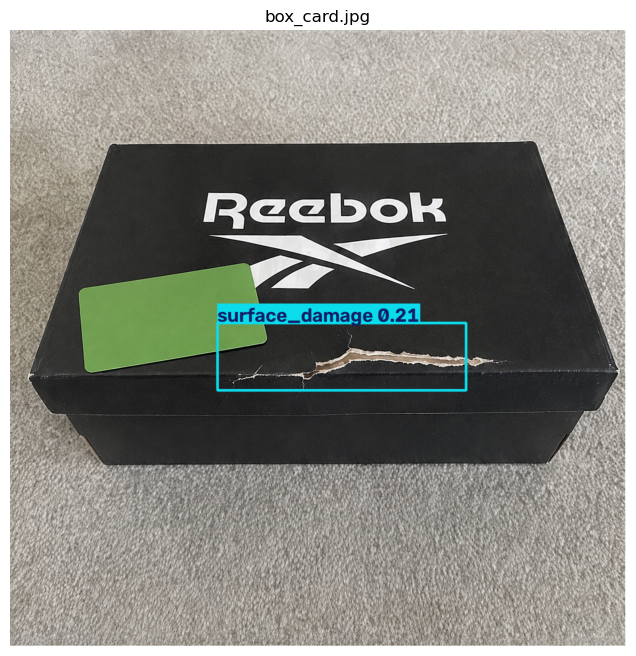

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO("weights.pt")

image_paths = [
    "box_card.jpg"
]

results = model(image_paths, conf=0.20, save=True)

for image_path, result in zip(image_paths, results):
    print(f"\nImage: {image_path}")

    if len(result.boxes) == 0:
        print("No damage detected")
    else:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            print("class:", class_name)
            print("confidence:", round(confidence, 3))
            print("bbox:", [round(v, 1) for v in (x1, y1, x2, y2)])

    plotted_image = result.plot()

    plt.figure(figsize=(10, 8))
    plt.imshow(plotted_image[:, :, ::-1])
    plt.axis("off")
    plt.title(image_path)
    plt.show()

# Store the exact image path and YOLO result for later cells
image_path = image_paths[0]
result = results[0]

In [3]:
image_paths = ["box_card.jpg"]

In [4]:
import cv2
import numpy as np

Candidate 1: area_ratio = 0.0613 aspect_ratio = 9.451 rectangularity = 0.926 long_side = 991.5 short_side = 104.9
Candidate 2: area_ratio = 0.0062 aspect_ratio = 1.878 rectangularity = 0.948 long_side = 139.0 short_side = 74.0
Candidate 3: area_ratio = 0.0185 aspect_ratio = 4.61 rectangularity = 0.936 long_side = 378.0 short_side = 82.0
Candidate 4: area_ratio = 0.0295 aspect_ratio = 7.435 rectangularity = 0.928 long_side = 609.6 short_side = 82.0
Candidate 5: area_ratio = 0.0073 aspect_ratio = 1.831 rectangularity = 0.792 long_side = 163.0 short_side = 89.0
Candidate 6: area_ratio = 0.0391 aspect_ratio = 2.165 rectangularity = 0.946 long_side = 375.1 short_side = 173.3
Candidate 7: area_ratio = 0.1986 aspect_ratio = 2.349 rectangularity = 0.608 long_side = 1098.2 short_side = 467.5
Candidate 8: area_ratio = 0.9984 aspect_ratio = 1.0 rectangularity = 1.0 long_side = 1253.0 short_side = 1253.0

Selected card candidate:
Candidate number: 6
Area ratio: 0.0391
Aspect ratio: 2.165
Rectangul

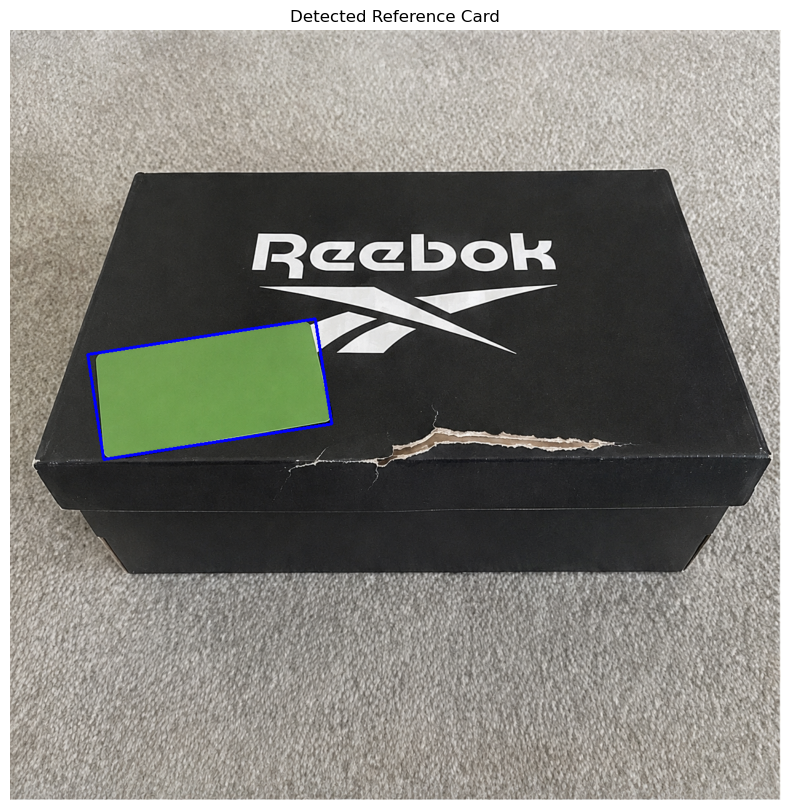

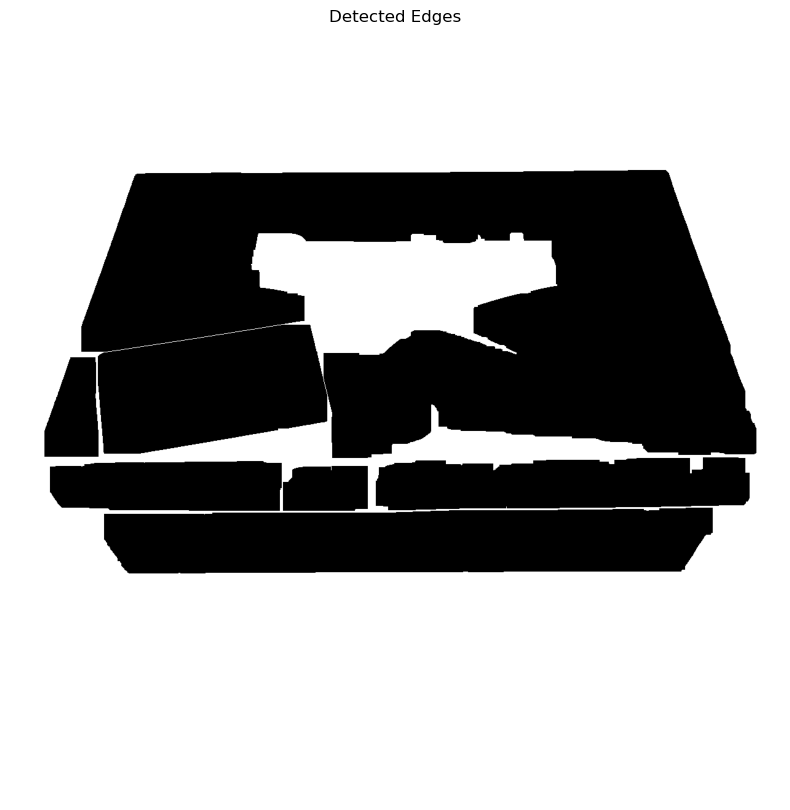

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Standard credit card dimensions
CARD_WIDTH_CM = 8.56
CARD_HEIGHT_CM = 5.398
CARD_ASPECT_RATIO = CARD_WIDTH_CM / CARD_HEIGHT_CM

# Read the same image used for YOLO inference
card_image = cv2.imread(image_path)

if card_image is None:
    raise FileNotFoundError(f"Cannot read image: {image_path}")

# Copy the original image for visualization
card_debug_image = card_image.copy()

# Get image dimensions
image_height, image_width = card_image.shape[:2]
image_area = image_height * image_width

# Convert the image to grayscale
gray = cv2.cvtColor(
    card_image,
    cv2.COLOR_BGR2GRAY
)

# Improve local contrast
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

gray_enhanced = clahe.apply(gray)

# Reduce noise while preserving object edges
blurred = cv2.bilateralFilter(
    gray_enhanced,
    9,
    60,
    60
)

# Detect edges with lower thresholds
edges = cv2.Canny(
    blurred,
    15,
    70
)

# Connect broken card edges
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (11, 11)
)

edges_closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=4
)

# Find all contours
contours, _ = cv2.findContours(
    edges_closed,
    cv2.RETR_LIST,
    cv2.CHAIN_APPROX_SIMPLE
)

card_contour = None
card_box = None
best_score = float("inf")
best_candidate_info = None

candidate_number = 0

for contour in contours:
    contour_area = cv2.contourArea(contour)

    if contour_area <= 0:
        continue

    # Fit a rotated rectangle directly to the contour
    rect = cv2.minAreaRect(contour)
    (_, _), (rect_width, rect_height), _ = rect

    if rect_width <= 0 or rect_height <= 0:
        continue

    long_side = max(rect_width, rect_height)
    short_side = min(rect_width, rect_height)

    if short_side <= 0:
        continue

    area_ratio = contour_area / image_area
    aspect_ratio = long_side / short_side

    rectangle_area = rect_width * rect_height

    if rectangle_area <= 0:
        continue

    rectangularity = contour_area / rectangle_area

    candidate_number += 1

    print(
        f"Candidate {candidate_number}:",
        "area_ratio =", round(area_ratio, 4),
        "aspect_ratio =", round(aspect_ratio, 3),
        "rectangularity =", round(rectangularity, 3),
        "long_side =", round(long_side, 1),
        "short_side =", round(short_side, 1)
    )

    # Ignore candidates smaller than the expected card size
    if area_ratio < 0.01:
        continue

    # Ignore large objects such as the shoe box
    if area_ratio > 0.10:
        continue

    # Allow perspective distortion and imperfect edge detection
    if not 1.35 <= aspect_ratio <= 2.35:
        continue

    # Require a reasonably complete rectangular region
    if rectangularity < 0.60:
        continue

    # Prevent tiny narrow regions from being selected
    if long_side < image_width * 0.15:
        continue

    if short_side < image_height * 0.08:
        continue

    # Prevent the shoe box from being selected
    if long_side > image_width * 0.50:
        continue

    if short_side > image_height * 0.35:
        continue

    # Measure difference from the standard card ratio
    ratio_difference = abs(
        aspect_ratio - CARD_ASPECT_RATIO
    )

    # The card in this image occupies about 4% of the image
    target_area_ratio = 0.04

    area_difference = abs(
        area_ratio - target_area_ratio
    )

    # Lower score means a better card candidate
    score = (
        ratio_difference * 0.55
        + area_difference * 4.0
        + (
            1.0
            - min(rectangularity, 1.0)
        ) * 0.25
    )

    if score < best_score:
        best_score = score
        card_contour = contour
        card_box = cv2.boxPoints(rect).astype(
            np.float32
        )

        best_candidate_info = {
            "candidate_number": candidate_number,
            "area_ratio": area_ratio,
            "aspect_ratio": aspect_ratio,
            "rectangularity": rectangularity,
            "long_side": long_side,
            "short_side": short_side
        }

if card_contour is None or card_box is None:
    raise ValueError(
        "Cannot find a reference card. "
        "Make sure the full card is visible and separated from the background."
    )

# Order the four card corners
point_sum = card_box.sum(axis=1)

point_difference = np.diff(
    card_box,
    axis=1
).reshape(-1)

top_left = card_box[
    np.argmin(point_sum)
]

bottom_right = card_box[
    np.argmax(point_sum)
]

top_right = card_box[
    np.argmin(point_difference)
]

bottom_left = card_box[
    np.argmax(point_difference)
]

# Measure the upper and lower card edges
top_width_pixels = np.linalg.norm(
    top_right - top_left
)

bottom_width_pixels = np.linalg.norm(
    bottom_right - bottom_left
)

# Measure the left and right card edges
left_height_pixels = np.linalg.norm(
    bottom_left - top_left
)

right_height_pixels = np.linalg.norm(
    bottom_right - top_right
)

# Average opposite sides for more stable measurements
card_width_pixels = (
    top_width_pixels
    + bottom_width_pixels
) / 2

card_height_pixels = (
    left_height_pixels
    + right_height_pixels
) / 2

# Ensure width represents the longer card side
if card_height_pixels > card_width_pixels:
    card_width_pixels, card_height_pixels = (
        card_height_pixels,
        card_width_pixels
    )

# Arrange the corners for drawing
card_box_ordered = np.array(
    [
        top_left,
        top_right,
        bottom_right,
        bottom_left
    ],
    dtype=np.int32
)

# Draw the detected card boundary
cv2.drawContours(
    card_debug_image,
    [card_box_ordered],
    0,
    (255, 0, 0),
    4
)

print("\nSelected card candidate:")
print(
    "Candidate number:",
    best_candidate_info["candidate_number"]
)
print(
    "Area ratio:",
    round(best_candidate_info["area_ratio"], 4)
)
print(
    "Aspect ratio:",
    round(best_candidate_info["aspect_ratio"], 3)
)
print(
    "Rectangularity:",
    round(best_candidate_info["rectangularity"], 3)
)
print(
    "Detection score:",
    round(best_score, 4)
)

print("\nCard measurements:")
print(
    "Top width in pixels:",
    round(top_width_pixels, 2)
)
print(
    "Bottom width in pixels:",
    round(bottom_width_pixels, 2)
)
print(
    "Left height in pixels:",
    round(left_height_pixels, 2)
)
print(
    "Right height in pixels:",
    round(right_height_pixels, 2)
)
print(
    "Final card width:",
    round(card_width_pixels, 2)
)
print(
    "Final card height:",
    round(card_height_pixels, 2)
)

# Display the detected card
plt.figure(figsize=(14, 10))
plt.imshow(
    cv2.cvtColor(
        card_debug_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.title("Detected Reference Card")
plt.show()

# Display the processed edges for debugging
plt.figure(figsize=(14, 10))
plt.imshow(
    edges_closed,
    cmap="gray"
)
plt.axis("off")
plt.title("Detected Edges")
plt.show()

In [6]:
if card_width_pixels is None or card_height_pixels is None:
    raise ValueError(
        "A reference card must be detected before calculating scale."
    )

# Calculate the horizontal image scale
pixels_per_cm_x = (
    card_width_pixels / CARD_WIDTH_CM
)

# Calculate the vertical image scale
pixels_per_cm_y = (
    card_height_pixels / CARD_HEIGHT_CM
)

# Calculate the average scale only for comparison
average_pixels_per_cm = (
    pixels_per_cm_x
    + pixels_per_cm_y
) / 2

# Measure the difference between the two directions
scale_difference_percent = (
    abs(pixels_per_cm_x - pixels_per_cm_y)
    / average_pixels_per_cm
    * 100
)

print(
    "Horizontal pixels per cm:",
    round(pixels_per_cm_x, 2)
)

print(
    "Vertical pixels per cm:",
    round(pixels_per_cm_y, 2)
)

print(
    "Average pixels per cm:",
    round(average_pixels_per_cm, 2)
)

print(
    "Scale difference:",
    round(scale_difference_percent, 2),
    "%"
)

# Warn when perspective distortion may be too large
if scale_difference_percent > 10:
    print(
        "Warning: The horizontal and vertical scales differ significantly."
    )
    print(
        "Retake the image with the camera facing the box more directly."
    )
else:
    print("Scale calibration completed successfully.")

Horizontal pixels per cm: 43.82
Vertical pixels per cm: 32.1
Average pixels per cm: 37.96
Scale difference: 30.89 %
Retake the image with the camera facing the box more directly.


Image used for measurement: box_card.jpg
YOLO result image size: 1254 x 1254
OpenCV image size: 1254 x 1254

Detection 1
Class: surface_damage
Confidence: 0.21
Bounding box: [422.2, 596.2, 928.6, 733.8]
Bounding box size in pixels: 506.5 x 137.6
Estimated damage size: 11.56 cm x 4.29 cm


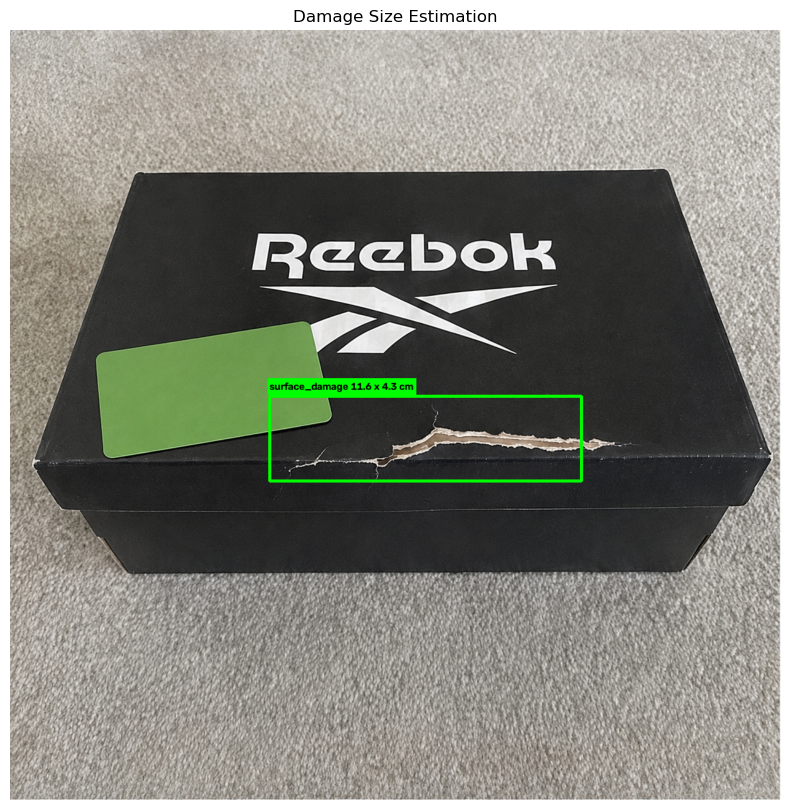

In [7]:
# Read the exact same image used for YOLO and card detection
measurement_image = cv2.imread(image_path)

if measurement_image is None:
    raise FileNotFoundError(
        f"Cannot read image: {image_path}"
    )

measurement_height, measurement_width = (
    measurement_image.shape[:2]
)

# Get the original image size stored in the YOLO result
result_height, result_width = result.orig_shape

print("Image used for measurement:", image_path)

print(
    "YOLO result image size:",
    result_width,
    "x",
    result_height
)

print(
    "OpenCV image size:",
    measurement_width,
    "x",
    measurement_height
)

# Prevent bounding boxes from being drawn on a different image
if (
    result_width != measurement_width
    or result_height != measurement_height
):
    raise ValueError(
        "The YOLO result and measurement image have different dimensions. "
        "Run the YOLO cell again using box_card.jpg."
    )

if len(result.boxes) == 0:
    print("No damage detected.")

else:
    for detection_number, box in enumerate(
        result.boxes,
        start=1
    ):
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])

        # Get coordinates mapped to the original image
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        # Calculate the bounding box size in pixels
        damage_width_pixels = x2 - x1
        damage_height_pixels = y2 - y1

        # Convert horizontal pixels using the horizontal scale
        damage_width_cm = (
            damage_width_pixels
            / pixels_per_cm_x
        )

        # Convert vertical pixels using the vertical scale
        damage_height_cm = (
            damage_height_pixels
            / pixels_per_cm_y
        )

        print(f"\nDetection {detection_number}")
        print("Class:", class_name)
        print("Confidence:", round(confidence, 3))

        print(
            "Bounding box:",
            [
                round(x1, 1),
                round(y1, 1),
                round(x2, 1),
                round(y2, 1)
            ]
        )

        print(
            "Bounding box size in pixels:",
            round(damage_width_pixels, 1),
            "x",
            round(damage_height_pixels, 1)
        )

        print(
            "Estimated damage size:",
            round(damage_width_cm, 2),
            "cm x",
            round(damage_height_cm, 2),
            "cm"
        )

        # Convert coordinates to integers only for drawing
        x1_int = int(round(x1))
        y1_int = int(round(y1))
        x2_int = int(round(x2))
        y2_int = int(round(y2))

        # Keep the coordinates inside the original image
        x1_int = max(
            0,
            min(x1_int, measurement_width - 1)
        )

        x2_int = max(
            0,
            min(x2_int, measurement_width - 1)
        )

        y1_int = max(
            0,
            min(y1_int, measurement_height - 1)
        )

        y2_int = max(
            0,
            min(y2_int, measurement_height - 1)
        )

        # Draw the original YOLO bounding box
        cv2.rectangle(
            measurement_image,
            (x1_int, y1_int),
            (x2_int, y2_int),
            (0, 255, 0),
            3
        )

        # Create the measurement label
        label = (
            f"{class_name} "
            f"{damage_width_cm:.1f} x "
            f"{damage_height_cm:.1f} cm"
        )

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.55
        thickness = 2

        # Calculate the label size
        (text_width, text_height), baseline = cv2.getTextSize(
            label,
            font,
            font_scale,
            thickness
        )

        # Place the label above the bounding box by default
        text_x = x1_int
        text_y = y1_int - 10

        # Move the label left if it would leave the right side
        if text_x + text_width > measurement_width:
            text_x = (
                measurement_width
                - text_width
                - 5
            )

        # Move the label below the box if there is no space above
        if text_y - text_height < 0:
            text_y = (
                y1_int
                + text_height
                + 10
            )

        # Keep the label inside the image
        text_x = max(5, text_x)

        text_y = max(
            text_height + 5,
            min(
                text_y,
                measurement_height
                - baseline
                - 5
            )
        )

        background_top_left = (
            max(0, text_x - 3),
            max(
                0,
                text_y - text_height - 4
            )
        )

        background_bottom_right = (
            min(
                measurement_width - 1,
                text_x + text_width + 3
            ),
            min(
                measurement_height - 1,
                text_y + baseline + 3
            )
        )

        # Draw a filled background behind the label
        cv2.rectangle(
            measurement_image,
            background_top_left,
            background_bottom_right,
            (0, 255, 0),
            -1
        )

        # Draw the label text
        cv2.putText(
            measurement_image,
            label,
            (text_x, text_y),
            font,
            font_scale,
            (0, 0, 0),
            thickness,
            cv2.LINE_AA
        )

# Display the final measurement result
plt.figure(figsize=(14, 10))
plt.imshow(
    cv2.cvtColor(
        measurement_image,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.title("Damage Size Estimation")
plt.show()

In [8]:
import shutil
from pathlib import Path

source_model = Path("weights.pt")
final_model = Path("resellbox_final.pt")

if not source_model.exists():
    raise FileNotFoundError(f"Cannot find model: {source_model}")

shutil.copy2(source_model, final_model)

print("Final model saved as:", final_model)
print("File size:", round(final_model.stat().st_size / (1024 ** 2), 2), "MB")

Final model saved as: resellbox_final.pt
File size: 18.29 MB


In [9]:
model = YOLO("resellbox_final.pt")

In [10]:
from ultralytics import YOLO

final_model = YOLO("resellbox_final.pt")

print("Class names:", final_model.names)
print("Model task:", final_model.task)

Class names: {0: 'dent', 1: 'surface_damage'}
Model task: detect


In [11]:
final_test_image = "box_card.jpg"

final_results = final_model(
    final_test_image,
    conf=0.20,
    verbose=False
)

final_result = final_results[0]

print("Number of detections:", len(final_result.boxes))

for box in final_result.boxes:
    class_id = int(box.cls[0])
    class_name = final_model.names[class_id]
    confidence = float(box.conf[0])
    bbox = box.xyxy[0].tolist()

    print("\nClass ID:", class_id)
    print("Class:", class_name)
    print("Confidence:", round(confidence, 3))
    print("BBox:", [round(value, 1) for value in bbox])

Number of detections: 1

Class ID: 1
Class: surface_damage
Confidence: 0.21
BBox: [422.2, 596.2, 928.6, 733.8]


In [12]:
FINAL_IMAGE_SIZE = 640
FINAL_CONFIDENCE = 0.20
FINAL_IOU_THRESHOLD = 0.70

final_results = final_model.predict(
    source=final_test_image,
    imgsz=FINAL_IMAGE_SIZE,
    conf=FINAL_CONFIDENCE,
    iou=FINAL_IOU_THRESHOLD,
    verbose=False
)

final_result = final_results[0]

print("Number of detections:", len(final_result.boxes))

for box in final_result.boxes:
    class_id = int(box.cls[0])
    class_name = final_model.names[class_id]
    confidence = float(box.conf[0])
    bbox = box.xyxy[0].tolist()

    print("\nClass ID:", class_id)
    print("Class:", class_name)
    print("Confidence:", round(confidence, 3))
    print("BBox:", [round(value, 1) for value in bbox])

Number of detections: 1

Class ID: 1
Class: surface_damage
Confidence: 0.21
BBox: [422.2, 596.2, 928.6, 733.8]


In [13]:
%pip install -U onnx onnxruntime onnxslim

Note: you may need to restart the kernel to use updated packages.


In [14]:
from ultralytics import YOLO
from pathlib import Path

PT_MODEL_PATH = "resellbox_final.pt"

if not Path(PT_MODEL_PATH).exists():
    raise FileNotFoundError(
        f"Cannot find model: {PT_MODEL_PATH}"
    )

export_model = YOLO(PT_MODEL_PATH)

onnx_path = export_model.export(
    format="onnx",
    imgsz=FINAL_IMAGE_SIZE,
    batch=1,
    dynamic=False,
    simplify=True,
    opset=17
)

print("ONNX model saved as:", onnx_path)

Ultralytics 8.4.107 🚀 Python-3.13.5 torch-2.13.0 CPU (Apple M1)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'resellbox_final.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (18.3 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.5s, saved as 'resellbox_final.onnx' (36.2 MB)

Export complete (2.0s)
Results saved to /Users/matthewkwon/Desktop/resell_box_ai/resellbox_final.onnx
Predict:         yolo predict task=detect model=resellbox_final.onnx imgsz=640 
Validate:        yolo val task=detect model=resellbox_final.onnx imgsz=640 data=/train/cache/dataset/data.yaml  
Visualize:       https://netron.app
ONNX model saved as: resellbox_final.onnx


In [15]:
onnx_model = YOLO("resellbox_final.onnx")

onnx_results = onnx_model.predict(
    source=final_test_image,
    imgsz=FINAL_IMAGE_SIZE,
    conf=FINAL_CONFIDENCE,
    iou=FINAL_IOU_THRESHOLD,
    verbose=False
)

onnx_result = onnx_results[0]

print("ONNX detections:", len(onnx_result.boxes))

for box in onnx_result.boxes:
    class_id = int(box.cls[0])
    class_name = onnx_model.names[class_id]
    confidence = float(box.conf[0])
    bbox = box.xyxy[0].tolist()

    print("\nClass ID:", class_id)
    print("Class:", class_name)
    print("Confidence:", round(confidence, 3))
    print("BBox:", [round(value, 1) for value in bbox])

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Loading resellbox_final.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
ONNX detections: 1

Class ID: 1
Class: surface_damage
Confidence: 0.21
BBox: [422.2, 596.2, 928.6, 733.8]


In [16]:
# Use the ONNX result for OpenCV measurement
model = onnx_model
result = onnx_result
image_path = final_test_image

print("OpenCV pipeline is now using the ONNX result.")

OpenCV pipeline is now using the ONNX result.
